# Zero-shot inference for label transfer in single-cell resolution spatial transcriptomics data

Here, we demonstrate how to perform label transfer using human [CosMx lung data](https://brukerspatialbiology.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/nsclc-ffpe-dataset/). This dataset contains three replicates of lung tissue samples with annotated cell type and niche labels.

In [1]:
from huggingface_hub import snapshot_download
import scanpy as sc
import torch
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from spaGFM.stRoamer.utils.data_build import initial_pyG_graph
from spaGFM.stRoamer.inference.run_inference import load_checkpoint, run_inference

/fs/ess/PAS1475/yzhong/sf_project/random_test/spaGFM_dev/08_27_26/spaGFM_1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-30 18:14:54,670 - datasets - INFO - PyTorch version 2.10.0+cu126 available.
2026-08-30 18:14:54,674 - datasets - INFO - JAX version 0.4.38 available.


In [2]:
# 1. Download the pretrained model
model_path = snapshot_download(
    repo_id="tinywind123/spaGFM",
    local_dir="spaGFM_model"
)

2026-08-30 18:15:01,357 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/tinywind123/spaGFM/revision/main "HTTP/1.1 200 OK"
Fetching 13 files: 100%|██████████| 13/13 [00:00<00:00, 228.54it/s]


We used the pre-trained spaGFM-317M model to perform zero-shot inference here.

In [3]:
# 2. Load the pretrained model
device = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
model = load_checkpoint(path=os.path.join(model_path, 'spaGFM/human_317M.pt'), 
                        device=device)

If spatial coordinates are saved in adata.obsm.['spatial'], coord_x and coord_y can be ignored.

In [4]:
# 3. Initialize graph using AnnData object
data_paths = sorted(glob.glob(os.path.join(model_path, 'demo_data/*.h5ad')))
lung5_adata_dict = {os.path.basename(path): sc.read_h5ad(path) for path in data_paths}
for key, adata in lung5_adata_dict.items():
    adata=initial_pyG_graph(
        adata,
        model_dir=os.path.join(model_path, 'scFM/scGPT_human'),
        gene_col='index',               # Column name of gene names in adata.var
        batch_size=256,                 # Batch size for node embedding initialization
        coord_x='raw_sdimx',            # Column name of x coordinates in adata.obs
        coord_y='raw_sdimy',            # Column name of y coordinates in adata.obs
    )
    lung5_adata_dict[key] = adata

scGPT - INFO - match 958/960 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 383/383 [00:33<00:00, 11.47it/s]
/fs/ess/PAS1475/yzhong/sf_project/codebase/G2PM_spatial/scFM/scGPT/scgpt/tasks/cell_emb.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


scGPT - INFO - match 958/960 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 414/414 [00:40<00:00, 10.23it/s]
/fs/ess/PAS1475/yzhong/sf_project/codebase/G2PM_spatial/scFM/scGPT/scgpt/tasks/cell_emb.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


scGPT - INFO - match 958/960 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 383/383 [00:30<00:00, 12.55it/s]
/fs/ess/PAS1475/yzhong/sf_project/codebase/G2PM_spatial/scFM/scGPT/scgpt/tasks/cell_emb.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scGPT']` of view, initializing view as actual.
  adata.obsm["X_scGPT"] = cell_embeddings


Here, we used walk length = 8, but you can also try other walk lengths (32, 64 etc.) to see if it improves the performance.

In [5]:
# 4. Run model inference with different walk lengths
model['params']['walk_length']=8        # i.e wl = 8
for key, adata in lung5_adata_dict.items():
    adata = run_inference(
        input_data=adata,
        model=model,
        device=device,
        batch_size=32,                  # Batch size for model inference
        use_amp=True                    # Whether to use automatic mixed precision
    )
    lung5_adata_dict[key] = adata

/fs/ess/PAS1475/yzhong/sf_project/codebase/G2PM_spatial/spaGFM/stRoamer/models/encoder.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(
2026-08-30 18:17:11,004 - spaGFM.stRoamer.inference.inference - INFO - Using the following device during inference: cuda:0
Embedding cells via spaGFM: 100%|██████████| 3063/3063 [01:47<00:00, 28.51batch/s]
2026-08-30 18:19:01,039 - spaGFM.stRoamer.inference.inference - INFO - Using the following device during inference: cuda:0
Embedding cells via spaGFM: 100%|██████████| 3307/3307 [01:56<00:00, 28.41batch/s]
2026-08-30 18:20:59,574 - spaGFM.stRoamer.inference.inference - INFO - Using the following device during inference: cuda:0
Embedding cells via spaGFM: 100%|██████████| 3057/3057 [01:46<00:00, 28.58batch/s]


In [6]:
# 5. Inspect adata objects
for name, adata in lung5_adata_dict.items():
    print(name)
    print(adata)

cosmx_human_lung_Lung5_Rep1.h5ad
AnnData object with n_obs × n_vars = 98002 × 958
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'raw_sdimx', 'raw_sdimy', 'raw_cell_ID', 'viz_sdimx', 'viz_sdimy', 'viz_cell_ID', 'cell_ID', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.CD298', 'Max.CD298', 'Mean.G', 'Max.G', 'Mean.Y', 'Max.Y', 'Mean.R', 'Max.R', 'Mean.DAPI', 'Max.DAPI', 'dualfiles', 'Slide_name', 'tissue', 'Run_name', 'ISH.concentration', 'Dash', 'slide_ID_numeric', 'Run_Tissue_name', 'Panel', 'Diversity', 'totalcounts', 'log10totalcounts', 'background', 'remove_flagged_cells', 'patient', 'cell_type', 'niche', 'prop_tumor_in_100_neighbors', 'n_counts', 'leiden'
    var: 'feat_ID', 'remove_flagged_genes', 'n_cells', 'index', 'id_in_vocab'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'pyG_graph'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_scGPT', 'X_node_emb_wl_8', 'X_subgraph_emb_wl_8'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
co

Here, we used Lung5_rep1 as the reference dataset and Lung5_rep2/Lung5_rep3 as the query dataset. Two types of label were used: cell type and niche.

In [7]:
# 6. Label transfer using KNN classifier
n_neighbors = 5

# Choose a reference sample from the names printed above.
reference_name = 'cosmx_human_lung_Lung5_Rep1.h5ad'
cell_emb_name = 'X_node_emb_wl_' + str(model['params']['walk_length'])
neighborhood_emb_name = 'X_subgraph_emb_wl_' + str(model['params']['walk_length'])

reference = lung5_adata_dict[reference_name]
targets = {name: adata for name, adata in lung5_adata_dict.items() if name != reference_name}

# Train KNN classifiers directly on the spaGFM embeddings.
cell_knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
cell_knn.fit(reference.obsm[cell_emb_name], reference.obs['cell_type'])
niche_knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
niche_knn.fit(reference.obsm[neighborhood_emb_name], reference.obs['niche'])

for name, adata in targets.items():
    adata.obs['pred_cell_type'] = cell_knn.predict(adata.obsm[cell_emb_name])
    adata.obs['pred_niche'] = niche_knn.predict(adata.obsm[neighborhood_emb_name])

# Use one label order across ground-truth and transferred plots.
cell_type_categories = np.unique(np.concatenate([adata.obs['cell_type'].astype(str)
                                                for adata in lung5_adata_dict.values()]))
niche_categories = np.unique(np.concatenate([adata.obs['niche'].astype(str)
                                            for adata in lung5_adata_dict.values()]))

def plot_spatial(ax, adata, label_key, categories, title):
    coordinates = adata.obsm['spatial']
    labels = adata.obs[label_key].astype('category').cat.set_categories(categories).cat.codes
    ax.scatter(coordinates[:, 0], coordinates[:, 1], c=labels,
               cmap='tab20',
               vmin=0, vmax=len(categories) - 1, s=2, linewidths=0)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])

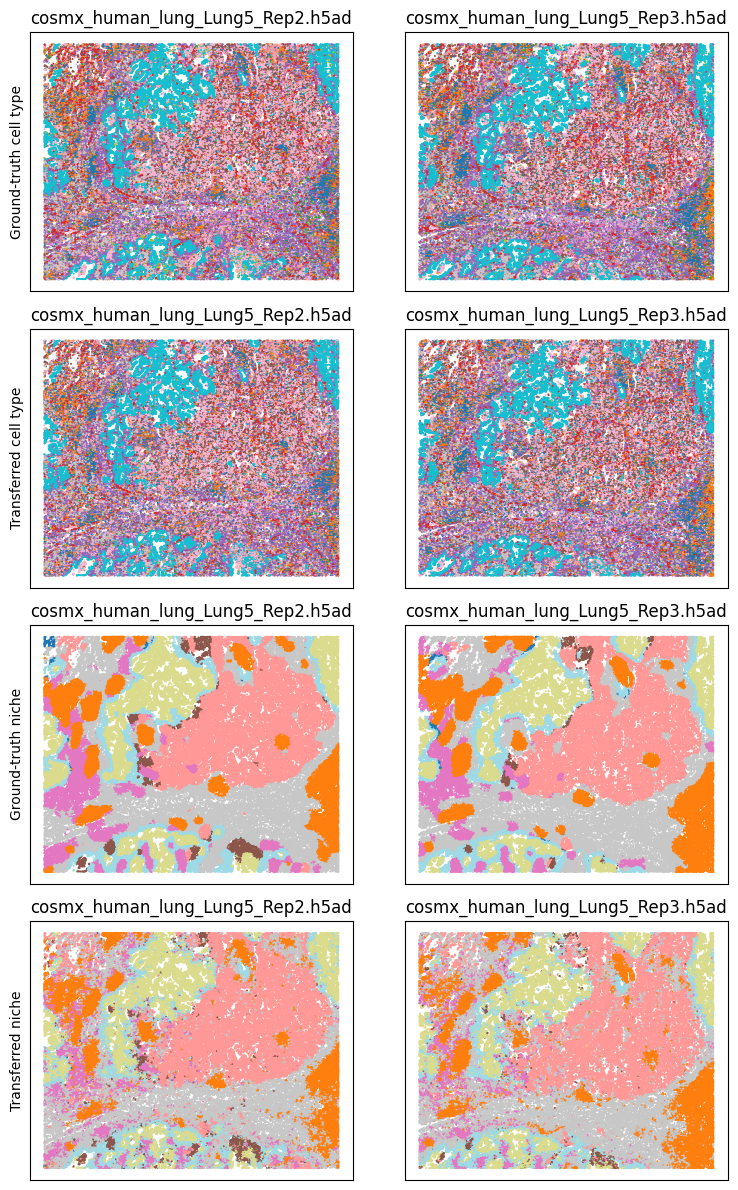

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(8, 12))
for column, (name, adata) in enumerate(targets.items()):
    plot_spatial(axes[0, column], adata, 'cell_type', cell_type_categories, name)
    plot_spatial(axes[1, column], adata, 'pred_cell_type', cell_type_categories, name)
    plot_spatial(axes[2, column], adata, 'niche', niche_categories, name)
    plot_spatial(axes[3, column], adata, 'pred_niche', niche_categories, name)

axes[0, 0].set_ylabel('Ground-truth cell type')
axes[1, 0].set_ylabel('Transferred cell type')
axes[2, 0].set_ylabel('Ground-truth niche')
axes[3, 0].set_ylabel('Transferred niche')
plt.tight_layout()
plt.show()